# Data Gathering/Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Muneeb Mughal\Desktop\folders\car analysis\CarRentalData.csv")


In [3]:
df.head(5)

,fuelType,rating,renterTripsTaken,reviewCount,location.city,location.country,location.latitude,location.longitude,location.state,owner.id,rate.daily,vehicle.make,vehicle.model,vehicle.type,vehicle.year
0,ELECTRIC,5.00,13,12,Seattle,US,47.449107,-122.308841,WA,12847615,135,Tesla,Model X,suv,2019
1,ELECTRIC,5.00,2,1,Tijeras,US,35.111060,-106.276551,NM,15621242,190,Tesla,Model X,suv,2018
2,HYBRID,4.92,28,24,Albuquerque,US,35.127163,-106.566681,NM,10199256,35,Toyota,Prius,car,2012
3,GASOLINE,5.00,21,20,Albuquerque,US,35.149726,-106.711425,NM,9365496,75,Ford,Mustang,car,2018
4,GASOLINE,5.00,3,1,Albuquerque,US,35.208659,-106.601008,NM,3553565,47,Chrysler,Sebring,car,2010


# Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5851 entries, 0 to 5850
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fuelType            5776 non-null   object 
 1   rating              5350 non-null   float64
 2   renterTripsTaken    5851 non-null   int64  
 3   reviewCount         5851 non-null   int64  
 4   location.city       5851 non-null   object 
 5   location.country    5851 non-null   object 
 6   location.latitude   5851 non-null   float64
 7   location.longitude  5851 non-null   float64
 8   location.state      5851 non-null   object 
 9   owner.id            5851 non-null   int64  
 10  rate.daily          5851 non-null   int64  
 11  vehicle.make        5851 non-null   object 
 12  vehicle.model       5851 non-null   object 
 13  vehicle.type        5851 non-null   object 
 14  vehicle.year        5851 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 685.8+

In [5]:
df.fuelType.isnull().sum()

np.int64(75)

In [6]:
total_null=df.fuelType.isnull().sum()/len(df.fuelType)*100

In [7]:
df.rating.isnull().sum()

np.int64(501)

In [8]:
total_null=df.rating.isnull().sum()/len(df.rating)*100
total_null

np.float64(8.562638865151257)

In [9]:
df.fuelType=df["fuelType"].fillna(df["fuelType"].mode()[0])
df.fuelType.isnull().sum()

np.int64(0)

In [48]:
df.rating=df.groupby("location.city")["rating"].transform(lambda x:x.fillna(x.median()))

In [11]:
df.rating.isnull().sum()

np.int64(100)

In [12]:
df["rating"].fillna(df["rating"].median(), inplace=True)


C:\Users\Muneeb Mughal\AppData\Local\Temp\ipykernel_15760\2355678787.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna(df["rating"].median(), inplace=True)


In [13]:
df.rating.isnull().sum()

np.int64(0)

In [14]:
df.isnull().sum()

fuelType              0
rating                0
renterTripsTaken      0
reviewCount           0
location.city         0
location.country      0
location.latitude     0
location.longitude    0
location.state        0
owner.id              0
rate.daily            0
vehicle.make          0
vehicle.model         0
vehicle.type          0
vehicle.year          0
dtype: int64

In [15]:
df.describe()

,rating,renterTripsTaken,reviewCount,location.latitude,location.longitude,owner.id,rate.daily,vehicle.year
count,5851.000000,5851.000000,5851.000000,5851.000000,5851.000000,5.851000e+03,5851.000000,5851.000000
mean,4.924991,33.477354,28.454794,35.582889,-99.632773,6.034830e+06,93.691506,2015.340113
std,0.176553,41.898954,35.136113,6.431408,20.391476,4.646022e+06,96.080920,4.050813
min,1.000000,0.000000,0.000000,21.272565,-158.165693,5.105000e+03,20.000000,1955.000000
25%,4.910000,5.000000,4.000000,30.453623,-117.158285,1.917451e+06,45.000000,2014.000000
50%,5.000000,18.000000,16.000000,35.554502,-95.673319,4.968749e+06,69.000000,2016.000000
75%,5.000000,46.000000,39.000000,39.996864,-81.538631,9.657496e+06,110.000000,2018.000000
max,5.000000,395.000000,321.000000,64.893610,-68.823637,1.581088e+07,1500.000000,2020.000000


# Solving Problem Statement

In [35]:
popularity=df.groupby(["location.city","vehicle.make","vehicle.model"])["renterTripsTaken"].mean().reset_index().sort_values(by="renterTripsTaken",ascending=False).head(5)
popularity

,location.city,vehicle.make,vehicle.model,renterTripsTaken
3356,Portland,Scion,xB,395.0
2757,New Orleans,FIAT,500,347.0
1834,Irving,Chevrolet,Cruze,296.0
2494,Miami,Mazda,6,295.0
2549,Millbrae,BMW,Z4,292.0


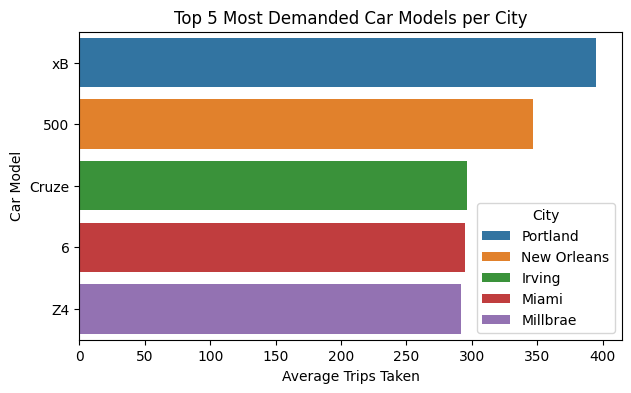

In [36]:
plt.figure(figsize=(7,4))
sns.barplot(
    x="renterTripsTaken", 
    y="vehicle.model", 
    hue="location.city",   # city color
    data=popularity, 
    dodge=False
)
plt.title("Top 5 Most Demanded Car Models per City")
plt.xlabel("Average Trips Taken")
plt.ylabel("Car Model")
plt.legend(title="City")
plt.show()


In [37]:
city_price = df.groupby("location.city")["rate.daily"].mean().reset_index().sort_values(by="rate.daily",ascending=False).head(10)
city_price

,location.city,rate.daily
886,Tyson’s,750.000000
572,Monument,603.000000
70,Beverly Hills,579.000000
194,Cromwell,549.000000
27,Ardmore,499.000000
246,East Brunswick,487.000000
549,Miami Beach,465.500000
67,Berwyn,425.000000
722,Reisterstown,410.500000
860,Sunny Isles Beach,406.888889


<Axes: xlabel='rate.daily', ylabel='location.city'>

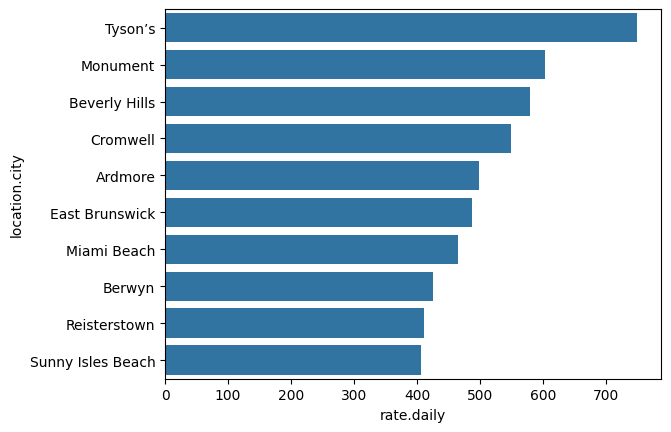

In [38]:
sns.barplot(x="rate.daily",y="location.city",data=city_price,dodge='auto')

In [39]:
# Aggregate per city
city_market = df.groupby("location.city").agg(
    total_cars=("vehicle.model", "count"),      # supply
    avg_demand=("renterTripsTaken", "mean")    # average trips per car
).head(10).reset_index().sort_values(by='total_cars',ascending=False)
city_market

,location.city,total_cars,avg_demand
6,Albuquerque,22,19.045455
5,Alameda,13,39.692308
9,Alexandria,10,21.500000
1,Addison,6,48.000000
2,Aiea,6,26.000000
0,Aberdeen Township,3,42.000000
4,Akron,2,34.000000
3,Airway Heights,1,9.000000
7,Aldie,1,1.000000
8,Alexander,1,9.000000


In [40]:
avg_total_cars = city_market["total_cars"].mean()
avg_demand = city_market["avg_demand"].mean()
avg_demand,avg_total_cars

(np.float64(24.923776223776223), np.float64(6.5))

In [41]:
def market_status(row):
    if row["total_cars"] > avg_total_cars and row["avg_demand"] < avg_demand:
        return "Oversaturated"
    elif row["total_cars"] < avg_total_cars and row["avg_demand"] > avg_demand:
        return "High Potential"
    else:
        return "Balanced"
city_market["market_type"] = city_market.apply(market_status, axis=1)


<Axes: xlabel='avg_demand', ylabel='location.city'>

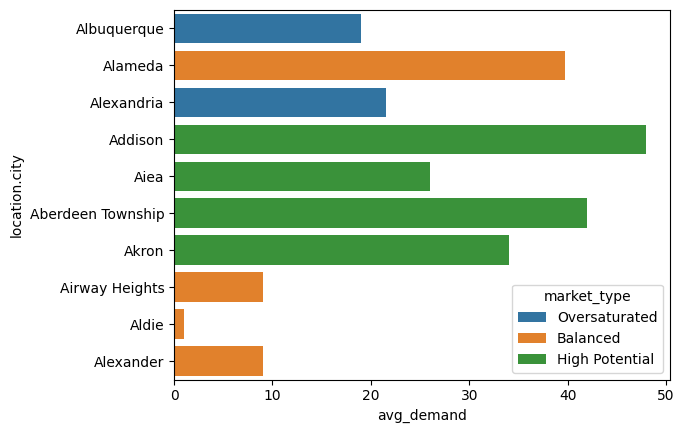

In [42]:
sns.barplot(x="avg_demand",y="location.city",data=city_market,hue="market_type" )

In [43]:
values=df["rating"].value_counts().sort_index()
values

rating
1.000       2
1.500       1
2.000       1
3.000       4
3.250       1
         ... 
4.980     149
4.985       3
4.990      91
4.995       2
5.000    3134
Name: count, Length: 99, dtype: int64

In [44]:
high_ratings = df[df["rating"] >= 4].shape[0]
total_ratings = df.shape[0]

percentage = (high_ratings / total_ratings) * 100

if percentage > 80:
    print("Ratings are inflated")
else:
    print("Ratings look genuine")

print("High rating percentage:", round(percentage, 2))


Ratings are inflated
High rating percentage: 99.68


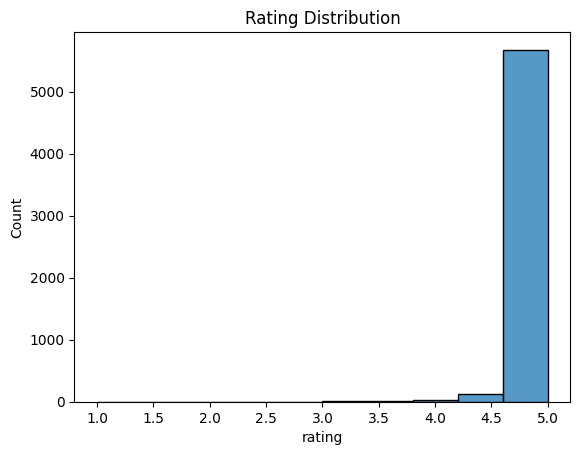

In [45]:
sns.histplot(df["rating"], bins=10)
plt.title("Rating Distribution")
plt.show()

In [27]:
df.columns

Index(['fuelType', 'rating', 'renterTripsTaken', 'reviewCount',
       'location.city', 'location.country', 'location.latitude',
       'location.longitude', 'location.state', 'owner.id', 'rate.daily',
       'vehicle.make', 'vehicle.model', 'vehicle.type', 'vehicle.year'],
      dtype='object')

# Hot encoding

In [28]:
df_model=pd.get_dummeies(df, columns=["vehicle.type", "fuelType", "location.state"], drop_first=True)

In [29]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5851 entries, 0 to 5850
Data columns (total 64 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rating                5851 non-null   float64
 1   renterTripsTaken      5851 non-null   int64  
 2   reviewCount           5851 non-null   int64  
 3   location.city         5851 non-null   object 
 4   location.country      5851 non-null   object 
 5   location.latitude     5851 non-null   float64
 6   location.longitude    5851 non-null   float64
 7   owner.id              5851 non-null   int64  
 8   rate.daily            5851 non-null   int64  
 9   vehicle.make          5851 non-null   object 
 10  vehicle.model         5851 non-null   object 
 11  vehicle.year          5851 non-null   int64  
 12  vehicle.type_minivan  5851 non-null   bool   
 13  vehicle.type_suv      5851 non-null   bool   
 14  vehicle.type_truck    5851 non-null   bool   
 15  vehicle.type_van     

# Modelling

In [30]:
X = df_model.drop(
    columns=[
        "renterTripsTaken ",
        "location.city",
        "location.country",
        "vehicle.make",
        "vehicle.model"
    ],
    errors="ignore"
)
y=df_model["renterTripsTaken"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)


In [34]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)*100
print("Regression Accuracy (R²):", r2)


Regression Accuracy (R²): 99.96085530364812
